# 03. 트리 앙상블

`RandomForestRegressor` → `HistGradientBoostingRegressor`.

로드맵 판정 기준: HistGBR이 `free_views_1_10` 단일회귀 베이스라인을 **유의미하게 못 이기고**
에러 분석에서 데이터 문제가 아님이 확인될 때만 DL을 검토한다.

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# 한글 라벨이 깨지지 않도록 (Windows 기본 폰트)
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["figure.figsize"] = (9, 4)


In [2]:
from sklearn.ensemble import HistGradientBoostingRegressor, RandomForestRegressor
from sklearn.inspection import permutation_importance

from service.model_training import (
    build_pipeline, cross_validate_model, evaluate, load_dataset,
    single_feature_baseline, split_xy, stratified_split, support_band, support_bounds,
)
from service.schema import NUMERIC_FEATURE_COLUMNS

labeled = load_dataset("labeled")
X, y = split_xy(labeled)
split = stratified_split(X, y)

In [3]:
results = {}
results["단일회귀 베이스라인"] = evaluate(
    split.y_test, single_feature_baseline(split.X_train, split.y_train, split.X_test)
)

candidates = {
    "random_forest": (RandomForestRegressor(n_estimators=300, min_samples_leaf=2,
                                            random_state=42, n_jobs=-1), True),
    "hist_gbr": (HistGradientBoostingRegressor(random_state=42), False),
}
fitted = {}
for name, (estimator, impute) in candidates.items():
    model = build_pipeline(estimator, impute_log_scale=impute)
    cv = cross_validate_model(model, split.X_train, split.y_train)
    model.fit(split.X_train, split.y_train)
    fitted[name] = model
    results[name] = {**evaluate(split.y_test, model.predict(split.X_test)), **cv}

pd.DataFrame(results).T[["log_rmse", "log_r2", "mdape", "spearman", "cv_log_rmse", "cv_log_rmse_std"]].round(4)

,log_rmse,log_r2,mdape,spearman,cv_log_rmse,cv_log_rmse_std
단일회귀 베이스라인,1.1114,0.7389,63.6426,0.8518,NaN,NaN
random_forest,0.9205,0.8209,51.6081,0.8871,0.9387,0.0120
hist_gbr,0.9036,0.8274,51.2881,0.8918,0.9221,0.0106


## 베이스라인 대비 개선폭

In [4]:
base = results["단일회귀 베이스라인"]["log_rmse"]
for name in candidates:
    gain = (base - results[name]["log_rmse"]) / base * 100
    print(f"{name:<16s} logRMSE {results[name]['log_rmse']:.4f}  (베이스라인 대비 {gain:+.1f}%)")

random_forest    logRMSE 0.9205  (베이스라인 대비 +17.2%)
hist_gbr         logRMSE 0.9036  (베이스라인 대비 +18.7%)


개선폭이 CV 표준편차의 몇 배인지 함께 보면 "유의미한가"를 판단할 수 있다.
개선이 뚜렷하면 DL을 검토할 이유가 없다(로드맵 C절).

## 피처 중요도 (permutation)

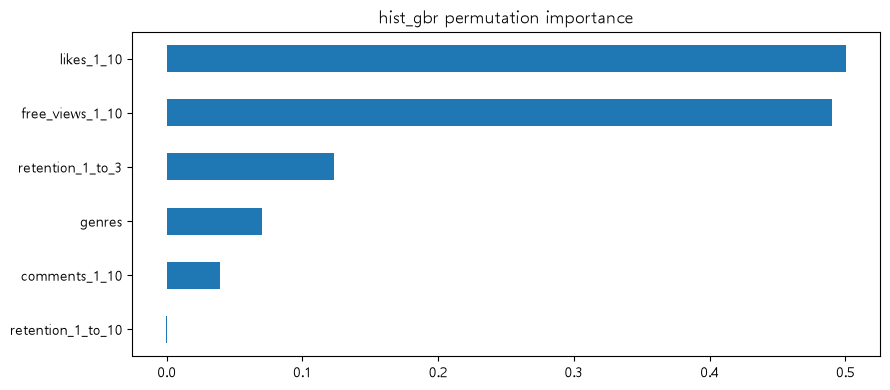

In [5]:
best_name = min(candidates, key=lambda n: results[n]["cv_log_rmse"])
best = fitted[best_name]
importance = permutation_importance(
    best, split.X_test, split.y_test, n_repeats=5, random_state=42, scoring="r2"
)
(
    pd.Series(importance.importances_mean, index=split.X_test.columns)
    .sort_values()
    .plot.barh(title=f"{best_name} permutation importance")
)
plt.tight_layout()

## 에러 분석 — 지지구간 밴드별

In [6]:
views = NUMERIC_FEATURE_COLUMNS[0]
bounds = support_bounds(split.X_train[views])
pred = best.predict(split.X_test)

analysis = pd.DataFrame({
    "밴드": support_band(split.X_test[views], bounds),
    "실제": split.y_test.to_numpy(),
    "예측": pred,
})
analysis["절대% 오차"] = (analysis["예측"] - analysis["실제"]).abs() / analysis["실제"] * 100
analysis.groupby("밴드").agg(건수=("실제", "size"), MdAPE=("절대% 오차", "median")).round(1)

,건수,MdAPE
밴드,,
정상,1628,51.5
희박(상한 초과),84,47.2
희박(하한 미만),86,56.4


Text(0.5, 1.0, 'hist_gbr — 예측 대 실제')

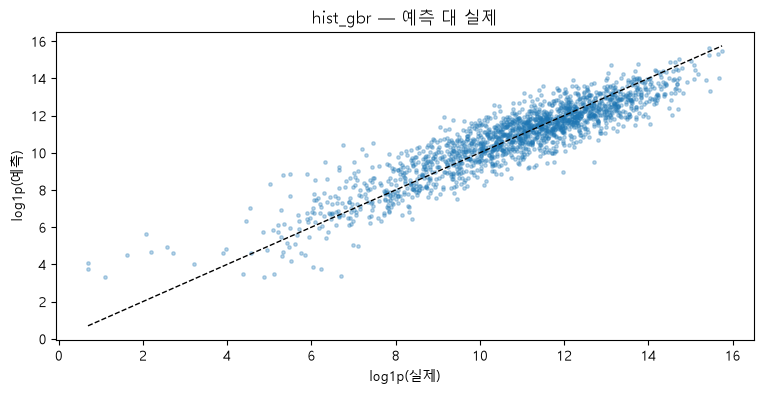

In [7]:
plt.scatter(np.log1p(analysis["실제"]), np.log1p(analysis["예측"]), s=6, alpha=.3)
lims = [np.log1p(analysis["실제"]).min(), np.log1p(analysis["실제"]).max()]
plt.plot(lims, lims, "k--", lw=1)
plt.xlabel("log1p(실제)")
plt.ylabel("log1p(예측)")
plt.title(f"{best_name} — 예측 대 실제")

희박 밴드에서 오차가 크게 벌어진다면, 그건 모델 결함이 아니라 **학습 데이터가 없는 구간**
이라는 뜻이다. 대시보드에서 밴드를 표기해야 하는 이유.

학습·저장은 `scripts/train_revenue_model.py`, 추론은 `scripts/predict_conversion_revenue.py`.